In [1]:
# !pip install optuna
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText
import random
import optuna

In [2]:
def plot_results(training_results, validation_results, best_epoch, best_train_loss, best_val_loss):
    # Extract loss data for training and validation
    train_loss = [epoch_data['loss'] for epoch_data in training_results]
    val_loss = [epoch_data['loss'] for epoch_data in validation_results]

    # Create subplots for loss
    _, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Plot loss
    axes[0].plot(train_loss, label='Training Loss')
    axes[0].plot(val_loss, label='Validation Loss')
    axes[0].axvline(best_epoch, color='red', linestyle='--', label=f'Best Epoch {best_epoch}')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    # Text box for best loss values
    loss_text = f'Best Epoch: {best_epoch}\nBest Train Loss: {best_train_loss:.4f}\nBest Val Loss: {best_val_loss:.4f}'
    anchored_text_loss = AnchoredText(loss_text, loc='center left', frameon=True, bbox_to_anchor=(1.05, 0.5), bbox_transform=axes[0].transAxes)
    axes[0].add_artist(anchored_text_loss)

    # Plotting validation loss on the second subplot
    axes[1].plot(val_loss, label='Validation Loss', color='orange')
    axes[1].axvline(best_epoch, color='red', linestyle='--', label=f'Best Epoch {best_epoch}')
    axes[1].set_title('Validation Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

### 1. Prepare Data

In [ ]:
from utils.giraffe_data_preparation import load_and_split_data, preview_data_shapes

# train_data, val_data, test_data = load_and_split_data("./dataset/chess_dataset.npz") # for local
train_data, val_data, test_data = load_and_split_data("girrafe_chess_dataset.npz") # for colab
(X_train_global, X_train_piece, X_train_square), y_train = train_data
(X_val_global, X_val_piece, X_val_square), y_val = val_data
(X_test_global, X_test_piece, X_test_square), y_test = test_data
preview_data_shapes(train_data, val_data, test_data)

======================== Train Set ========================
Global Features Shape: (600000, 15)
Piece-Centric Features Shape: (600000, 208)
Square-Centric Features Shape: (600000, 128)
Labels Shape: (600000,)

Random Train Sample:
Global Features: [-1.  0.  0.  0.  0.  7.  2.  1.  2.  1.  7.  2.  1.  2.  1.]
Piece-Centric Features: [ 0.          0.14285715  1.          0.          3.          0.14285715
  0.14285715  1.          0.          0.          0.2857143   0.14285715
  1.          0.          0.          0.71428573  0.14285715  1.
  0.          9.          0.85714287  0.14285715  1.          0.
  3.          1.          0.14285715  1.          0.         12.
  0.5714286   0.42857143  1.          3.          3.          0.
  0.          0.          0.          0.          0.2857143   0.2857143
  1.          0.          1.          0.          0.          0.
  0.          0.          0.71428573  0.          1.          0.
  5.          0.42857143  0.14285715  1.          0.      

0 ratings count: 9622


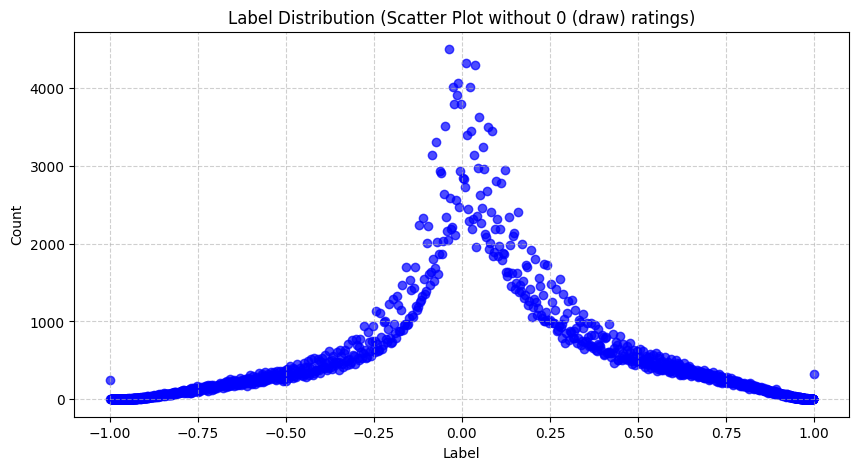

In [ ]:
unique, counts = np.unique(y_train, return_counts=True)
non_zero_labels = unique[unique != 0]
non_zero_counts = counts[unique != 0]
zero_counts = counts[unique == 0]
print(f"0 ratings count: {zero_counts.sum()}")
plt.figure(figsize=(10, 5))
plt.scatter(non_zero_labels, non_zero_counts, color="blue", alpha=0.7)
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Label Distribution (Scatter Plot without 0 (draw) ratings)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

## Giraffe Model (following recommendation from Matthew Lai)

### 2. Giraffe Model Architecture

In [ ]:
class GiraffeModelSeparation(nn.Module):
    def __init__(self, global_dim, piece_dim, square_dim):
        super(GiraffeModelSeparation, self).__init__()

        # Separate processing layers for each feature type
        self.global_fc = nn.Sequential(
            nn.Linear(global_dim, 8),
            nn.ReLU(),
            nn.Dropout(0.5)
        )

        self.piece_fc = nn.Sequential(
            nn.Linear(piece_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.5)
        )

        self.square_fc = nn.Sequential(
            nn.Linear(square_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.5)
        )

        # Fully connected layers after merging (based on network architecture provided)
        self.combined_fc = nn.Sequential(
            nn.Linear(8+64+32, 32),
            nn.ReLU(),
            nn.Dropout(0.5), # dropout after the combined layers
            nn.Linear(32, 1), # single output node
            nn.Tanh() # output between -1 and 1
        )

    def forward(self, X_g, X_p, X_s):
        x_g = self.global_fc(X_g)
        x_p = self.piece_fc(X_p)
        x_s = self.square_fc(X_s)

        # Concatenate the outputs from the three modules
        x = torch.cat((x_g, x_p, x_s), dim=1)

        # Pass through the combined fully connected layers
        x = self.combined_fc(x)
        return x

### 3. Train Model

In [ ]:
def train_model(train_data, val_data, epochs=100, batch_size=256, lr=0.0001):
    (X_train_global, X_train_piece, X_train_square), y_train = train_data
    (X_val_global, X_val_piece, X_val_square), y_val = val_data

    y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
    y_val = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = GiraffeModelSeparation(X_train_global.shape[1], X_train_piece.shape[1], X_train_square.shape[1]).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.MSELoss() # regression task, using MSE loss

    # Create DataLoader
    train_dataset = TensorDataset(torch.tensor(X_train_global, dtype=torch.float32),
                                  torch.tensor(X_train_piece, dtype=torch.float32),
                                  torch.tensor(X_train_square, dtype=torch.float32),
                                  y_train.clone().detach())
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    val_dataset = TensorDataset(torch.tensor(X_val_global, dtype=torch.float32),
                                torch.tensor(X_val_piece, dtype=torch.float32),
                                torch.tensor(X_val_square, dtype=torch.float32),
                                y_val.clone().detach())
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.3, patience=5)

    # Training loop
    best_val_loss = float("inf")
    best_epoch = -1
    best_model_path = "./models/best_giraffe_model_separation.pth"

    training_results = []
    validation_results = []

    model.train()
    for epoch in range(epochs):
        total_loss = 0

        for X_g, X_p, X_s, y in train_loader:
            X_g, X_p, X_s, y = X_g.to(device), X_p.to(device), X_s.to(device), y.to(device)
            optimizer.zero_grad()
            y_pred = model(X_g, X_p, X_s)
            loss = criterion(y_pred, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_g, X_p, X_s, y in val_loader:
                X_g, X_p, X_s, y = X_g.to(device), X_p.to(device), X_s.to(device), y.to(device)
                y_pred = model(X_g, X_p, X_s)
                loss = criterion(y_pred, y)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)

        # Store results for plotting
        training_results.append({'loss': avg_train_loss})
        validation_results.append({'loss': avg_val_loss})

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
        scheduler.step(avg_val_loss)

        # Save the best model based on validation loss
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_epoch = epoch
            torch.save(model.state_dict(), best_model_path)

    # Return best results and the trained model
    return training_results, validation_results, best_epoch, best_val_loss

training_results, validation_results, best_epoch, best_val_loss = train_model(train_data, val_data)

Epoch 1/100 - Train Loss: 0.1488, Val Loss: 0.1373
Epoch 2/100 - Train Loss: 0.1279, Val Loss: 0.1207
Epoch 3/100 - Train Loss: 0.1147, Val Loss: 0.1102
Epoch 4/100 - Train Loss: 0.1070, Val Loss: 0.1051
Epoch 5/100 - Train Loss: 0.1025, Val Loss: 0.1012
Epoch 6/100 - Train Loss: 0.0989, Val Loss: 0.0983
Epoch 7/100 - Train Loss: 0.0961, Val Loss: 0.0963
Epoch 8/100 - Train Loss: 0.0940, Val Loss: 0.0942
Epoch 9/100 - Train Loss: 0.0924, Val Loss: 0.0929
Epoch 10/100 - Train Loss: 0.0911, Val Loss: 0.0918
Epoch 11/100 - Train Loss: 0.0900, Val Loss: 0.0911
Epoch 12/100 - Train Loss: 0.0891, Val Loss: 0.0905
Epoch 13/100 - Train Loss: 0.0882, Val Loss: 0.0900
Epoch 14/100 - Train Loss: 0.0875, Val Loss: 0.0892
Epoch 15/100 - Train Loss: 0.0869, Val Loss: 0.0887
Epoch 16/100 - Train Loss: 0.0863, Val Loss: 0.0891
Epoch 17/100 - Train Loss: 0.0857, Val Loss: 0.0880
Epoch 18/100 - Train Loss: 0.0852, Val Loss: 0.0877
Epoch 19/100 - Train Loss: 0.0846, Val Loss: 0.0873
Epoch 20/100 - Train 

#### 3a. Visualise Best Model

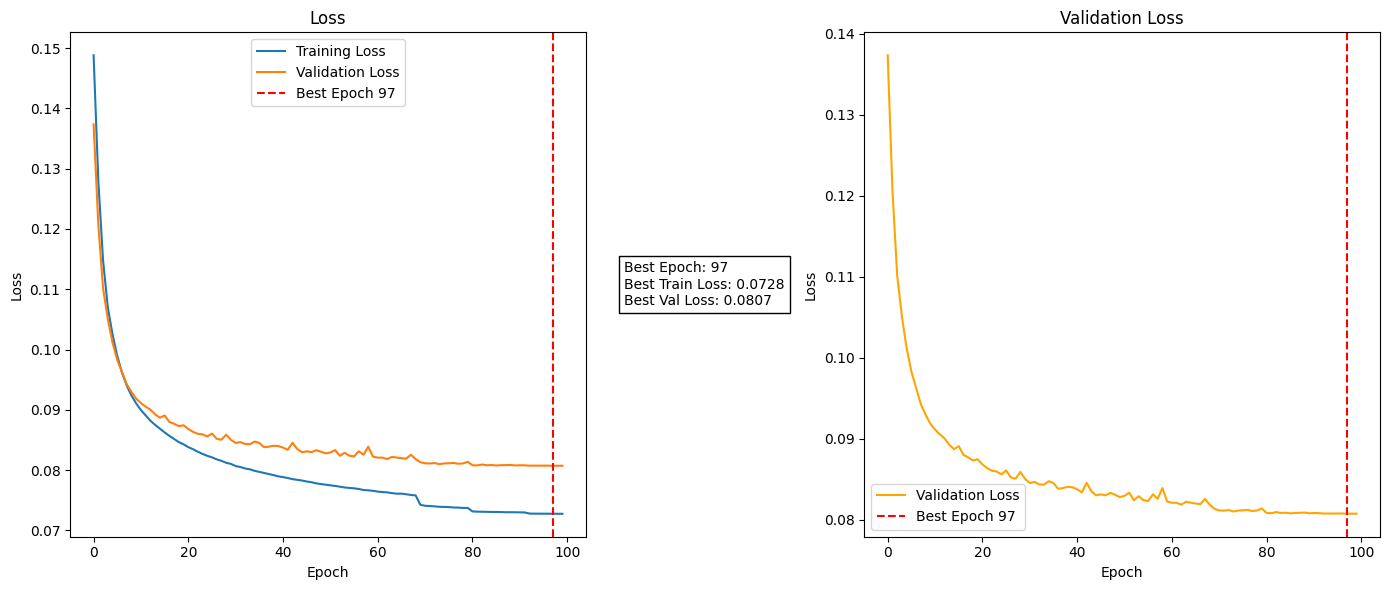

In [ ]:
best_train_loss = min([epoch_data['loss'] for epoch_data in training_results])
plot_results(training_results, validation_results, best_epoch, best_train_loss, best_val_loss)

### 4. Test Model

Test Loss: 0.0808
RMSE: 0.2843


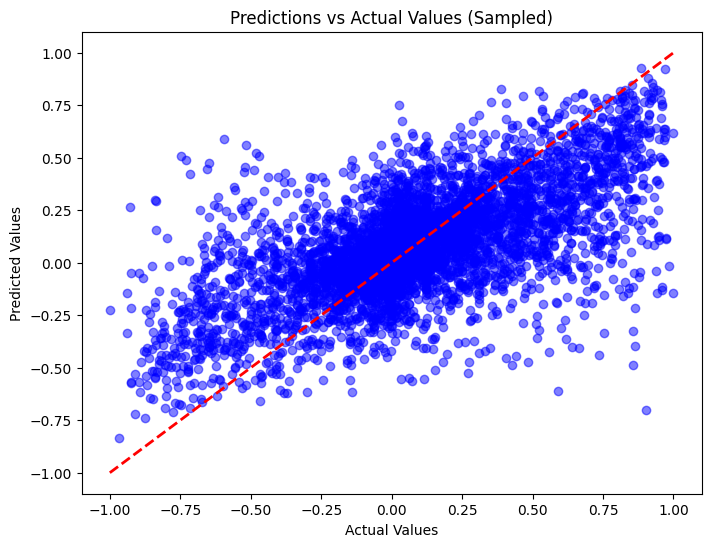

In [ ]:
def test_model_separation(model, test_data, batch_size=512):
    # Prepare test data
    (X_test_global, X_test_piece, X_test_square), y_test = test_data
    y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    # Create DataLoader for test data
    test_dataset = TensorDataset(torch.tensor(X_test_global, dtype=torch.float32),
                                 torch.tensor(X_test_piece, dtype=torch.float32),
                                 torch.tensor(X_test_square, dtype=torch.float32),
                                 y_test.clone().detach())
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # Evaluate the model
    model.eval()
    y_true = []
    y_pred = []
    test_loss = 0
    criterion = torch.nn.MSELoss()

    with torch.no_grad():
        for X_g, X_p, X_s, y in test_loader:
            X_g, X_p, X_s, y = X_g.to(device), X_p.to(device), X_s.to(device), y.to(device)
            y_hat = model(X_g, X_p, X_s)
            loss = criterion(y_hat, y)
            test_loss += loss.item()

            y_true.append(y.cpu().numpy())
            y_pred.append(y_hat.cpu().numpy())

    avg_test_loss = test_loss / len(test_loader)

    # Flatten the list of true and predicted values
    y_true = np.concatenate(y_true, axis=0)
    y_pred = np.concatenate(y_pred, axis=0)

    # Calculate RMSE
    rmse = np.sqrt(avg_test_loss)

    print(f"Test Loss: {avg_test_loss:.4f}")
    print(f"RMSE: {rmse:.4f}")

    # Plot predictions vs actual values
    sample_size = 5000
    indices = random.sample(range(len(y_true)), min(sample_size, len(y_true)))
    y_true_sampled = np.array(y_true)[indices]
    y_pred_sampled = np.array(y_pred)[indices]

    plt.figure(figsize=(8, 6))
    plt.scatter(y_true_sampled, y_pred_sampled, alpha=0.5, color='blue', label="Predictions")
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--', lw=2, label="Perfect Fit")
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title('Predictions vs Actual Values (Sampled)')
    plt.show()

    return rmse

model = GiraffeModelSeparation(X_train_global.shape[1], X_train_piece.shape[1], X_train_square.shape[1]) # initialise model with the same architecture
model.load_state_dict(torch.load("./models/best_giraffe_model_separation.pth", weights_only=True))
rmse = test_model_separation(model, test_data)

## Giraffe model (without modular separation)

### 6. Giraffe Model Architecture

In [ ]:
class GiraffeModelNoSeparation(nn.Module):
    def __init__(self, input_dim):
        super(GiraffeModelNoSeparation, self).__init__()

        self.fc = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(32, 1),
            nn.Tanh() # output between -1 and 1
        )

    def forward(self, X):
        return self.fc(X)

### 7. Train Model

In [ ]:
def train_model_no_separation(train_data, val_data, epochs=100, batch_size=256, lr=0.0001):
    (X_train_global, X_train_piece, X_train_square), y_train = train_data
    (X_val_global, X_val_piece, X_val_square), y_val = val_data

    # Concatenate inputs into a single tensor
    X_train_global = torch.tensor(X_train_global, dtype=torch.float32)
    X_train_piece = torch.tensor(X_train_piece, dtype=torch.float32)
    X_train_square = torch.tensor(X_train_square, dtype=torch.float32)

    X_val_global = torch.tensor(X_val_global, dtype=torch.float32)
    X_val_piece = torch.tensor(X_val_piece, dtype=torch.float32)
    X_val_square = torch.tensor(X_val_square, dtype=torch.float32)

    X_train = torch.cat((X_train_global, X_train_piece, X_train_square), dim=1).clone().detach()
    X_val = torch.cat((X_val_global, X_val_piece, X_val_square), dim=1).clone().detach()

    y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
    y_val = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    input_dim = X_train.shape[1]
    model = GiraffeModelNoSeparation(input_dim).to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.MSELoss() # using MSE loss for regression
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.3, patience=5)

    # Create DataLoaders
    train_dataset = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    val_dataset = TensorDataset(X_val, y_val)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Training loop
    best_val_loss = float("inf")
    best_epoch = -1
    best_model_path = "./models/best_giraffe_model_no_separation.pth"

    training_results = []
    validation_results = []

    model.train()
    for epoch in range(epochs):
        total_loss = 0

        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            y_pred = model(X)
            loss = criterion(y_pred, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                y_pred = model(X)
                loss = criterion(y_pred, y)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)

        training_results.append({'loss': avg_train_loss})
        validation_results.append({'loss': avg_val_loss})

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
        scheduler.step(avg_val_loss)

        # Save best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_epoch = epoch
            torch.save(model.state_dict(), best_model_path)

    return training_results, validation_results, best_epoch, best_val_loss

training_results, validation_results, best_epoch, best_val_loss = train_model_no_separation(train_data, val_data)

Epoch 1/100 - Train Loss: 0.1434, Val Loss: 0.1339
Epoch 2/100 - Train Loss: 0.1241, Val Loss: 0.1196
Epoch 3/100 - Train Loss: 0.1159, Val Loss: 0.1129
Epoch 4/100 - Train Loss: 0.1097, Val Loss: 0.1087
Epoch 5/100 - Train Loss: 0.1055, Val Loss: 0.1050
Epoch 6/100 - Train Loss: 0.1020, Val Loss: 0.1021
Epoch 7/100 - Train Loss: 0.0988, Val Loss: 0.0998
Epoch 8/100 - Train Loss: 0.0962, Val Loss: 0.0977
Epoch 9/100 - Train Loss: 0.0942, Val Loss: 0.0963
Epoch 10/100 - Train Loss: 0.0927, Val Loss: 0.0954
Epoch 11/100 - Train Loss: 0.0913, Val Loss: 0.0945
Epoch 12/100 - Train Loss: 0.0903, Val Loss: 0.0934
Epoch 13/100 - Train Loss: 0.0893, Val Loss: 0.0935
Epoch 14/100 - Train Loss: 0.0886, Val Loss: 0.0925
Epoch 15/100 - Train Loss: 0.0879, Val Loss: 0.0921
Epoch 16/100 - Train Loss: 0.0872, Val Loss: 0.0919
Epoch 17/100 - Train Loss: 0.0867, Val Loss: 0.0915
Epoch 18/100 - Train Loss: 0.0861, Val Loss: 0.0911
Epoch 19/100 - Train Loss: 0.0857, Val Loss: 0.0912
Epoch 20/100 - Train 

#### 7a. Visualise Best Model

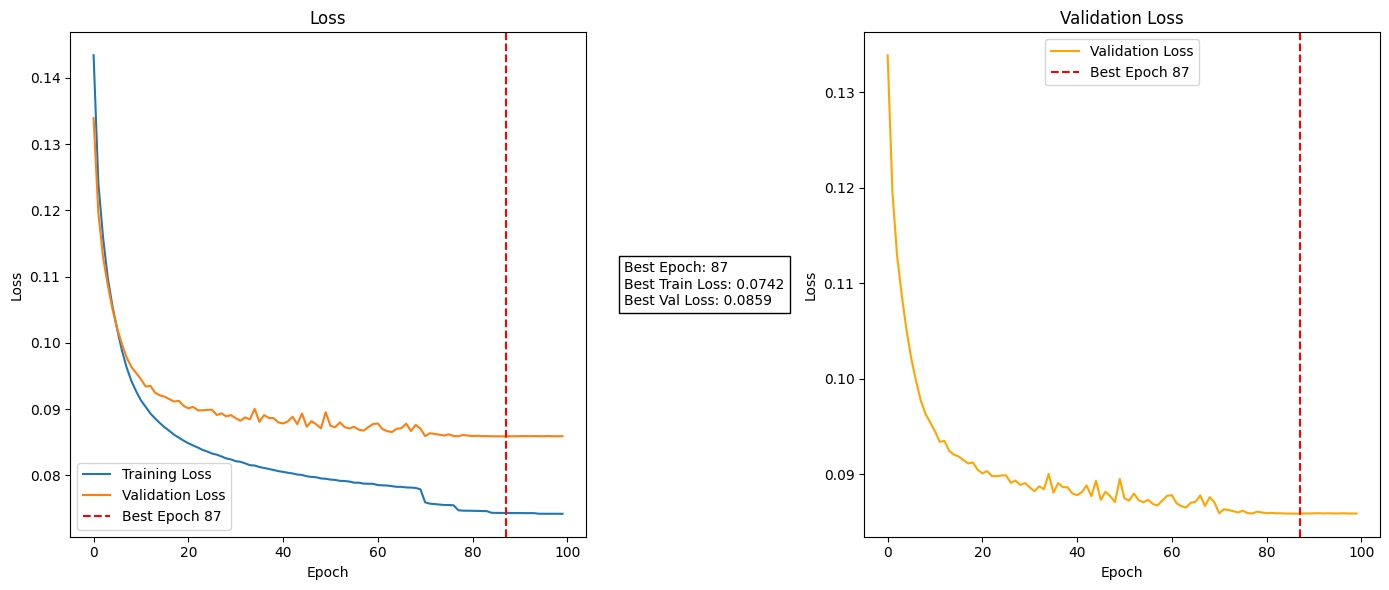

In [ ]:
best_train_loss = min([epoch_data['loss'] for epoch_data in training_results])
plot_results(training_results, validation_results, best_epoch, best_train_loss, best_val_loss)

### 8. Test Model

Test Loss: 0.0856
RMSE: 0.2925


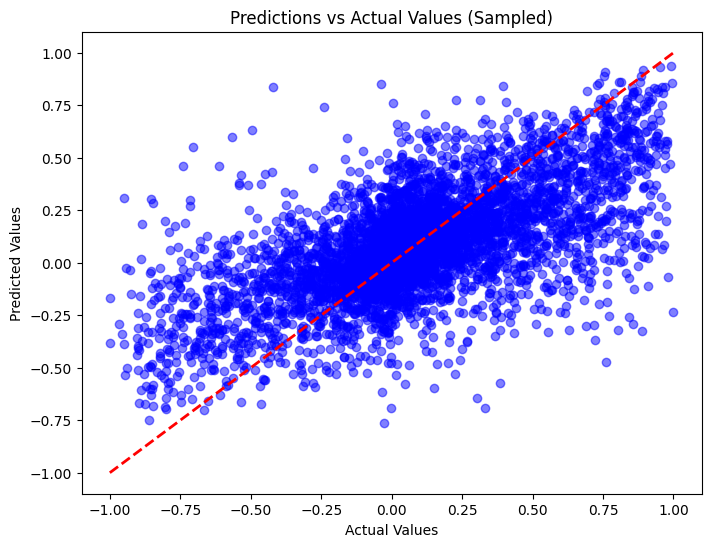

In [ ]:
def test_model(model, test_data, batch_size=512):
    # Prepare test data
    (X_test_global, X_test_piece, X_test_square), y_test = test_data

    # Concatenate inputs (global, piece, square features)
    X_test_global = torch.tensor(X_test_global, dtype=torch.float32)
    X_test_piece = torch.tensor(X_test_piece, dtype=torch.float32)
    X_test_square = torch.tensor(X_test_square, dtype=torch.float32)
    X_test = torch.cat((X_test_global, X_test_piece, X_test_square), dim=1)
    y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    # Create DataLoader for test data
    test_dataset = TensorDataset(X_test, y_test)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # Evaluate the model
    model.eval()
    y_true = []
    y_pred = []
    test_loss = 0
    criterion = torch.nn.MSELoss()

    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            y_hat = model(X)
            loss = criterion(y_hat, y)
            test_loss += loss.item()

            y_true.append(y.cpu().numpy())
            y_pred.append(y_hat.cpu().numpy())

    avg_test_loss = test_loss / len(test_loader)

    # Flatten the list of true and predicted values
    y_true = np.concatenate(y_true, axis=0)
    y_pred = np.concatenate(y_pred, axis=0)

    # Calculate RMSE
    rmse = np.sqrt(avg_test_loss)

    print(f"Test Loss: {avg_test_loss:.4f}")
    print(f"RMSE: {rmse:.4f}")

    # Plot predictions vs actual values
    sample_size = 5000
    indices = random.sample(range(len(y_true)), min(sample_size, len(y_true)))
    y_true_sampled = np.array(y_true)[indices]
    y_pred_sampled = np.array(y_pred)[indices]

    plt.figure(figsize=(8, 6))
    plt.scatter(y_true_sampled, y_pred_sampled, alpha=0.5, color='blue')
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--', lw=2)
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title('Predictions vs Actual Values (Sampled)')
    plt.show()

    return rmse

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = X_train_global.shape[1] + X_train_piece.shape[1] + X_train_square.shape[1] # concatenate input sizes

model = GiraffeModelNoSeparation(input_dim).to(device)
model.load_state_dict(torch.load("./models/best_giraffe_model_no_separation.pth", weights_only=True))
model.eval()

rmse = test_model(model, test_data)

## Comparison and Conclusion

Giraffe model with modular separation has a lower RMSE than the model without modular separation, therefore we will proceed to optimise the latter.

### 9. Optimize Better Model using Bayesian Optimization

In [ ]:
class GiraffeModelFinal(nn.Module):
    def __init__(self, global_dim, piece_dim, square_dim, global_nodes, piece_nodes, square_nodes, fc_nodes, dropout_rate):
        super(GiraffeModelFinal, self).__init__()

        self.global_fc = nn.Sequential(
            nn.Linear(global_dim, global_nodes),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )

        self.piece_fc = nn.Sequential(
            nn.Linear(piece_dim, piece_nodes),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )

        self.square_fc = nn.Sequential(
            nn.Linear(square_dim, square_nodes),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )

        self.combined_fc = nn.Sequential(
            nn.Linear(global_nodes+piece_nodes+square_nodes, fc_nodes),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(fc_nodes, 1),
            nn.Tanh()
        )

    def forward(self, X_g, X_p, X_s):
        x_g = self.global_fc(X_g)
        x_p = self.piece_fc(X_p)
        x_s = self.square_fc(X_s)
        x = torch.cat((x_g, x_p, x_s), dim=1)
        return self.combined_fc(x)

# Objective function for Bayesian Optimization
def objective(trial):
    # Sample hyperparameters
    global_nodes = trial.suggest_int("global_nodes", 4, 32, step=4)
    piece_nodes = trial.suggest_int("piece_nodes", 32, 128, step=16)
    square_nodes = trial.suggest_int("square_nodes", 16, 64, step=8)
    fc_nodes = trial.suggest_int("fc_nodes", 16, 128, step=16)
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.6, step=0.1)
    lr = trial.suggest_float("learning_rate", 1e-5, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [256, 512, 1024])

    # Prepare data
    (X_train_global, X_train_piece, X_train_square), y_train = train_data
    (X_val_global, X_val_piece, X_val_square), y_val = val_data

    y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
    y_val = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

    train_dataset = TensorDataset(torch.tensor(X_train_global, dtype=torch.float32),
                                  torch.tensor(X_train_piece, dtype=torch.float32),
                                  torch.tensor(X_train_square, dtype=torch.float32),
                                  y_train)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)

    val_dataset = TensorDataset(torch.tensor(X_val_global, dtype=torch.float32),
                                torch.tensor(X_val_piece, dtype=torch.float32),
                                torch.tensor(X_val_square, dtype=torch.float32),
                                y_val)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    # Model initialization
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = GiraffeModelFinal(X_train_global.shape[1], X_train_piece.shape[1], X_train_square.shape[1],
                         global_nodes, piece_nodes, square_nodes, fc_nodes, dropout_rate).to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.3, patience=5)

    model.train()
    for epoch in range(50):
        total_loss = 0
        for X_g, X_p, X_s, y in train_loader:
            X_g, X_p, X_s, y = X_g.to(device), X_p.to(device), X_s.to(device), y.to(device)
            optimizer.zero_grad()
            y_pred = model(X_g, X_p, X_s)
            loss = criterion(y_pred, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_g, X_p, X_s, y in val_loader:
                X_g, X_p, X_s, y = X_g.to(device), X_p.to(device), X_s.to(device), y.to(device)
                y_pred = model(X_g, X_p, X_s)
                loss = criterion(y_pred, y)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)
        scheduler.step(avg_val_loss)

        # Early stopping
        trial.report(avg_val_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return avg_val_loss # return validation loss as the optimization metric


# Run Bayesian Optimization
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20)

# Print best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-02-07 16:51:29,878] A new study created in memory with name: no-name-1d6077d7-c13f-4a94-94e9-c140b21e5aeb
[I 2025-02-07 17:03:26,906] Trial 0 finished with value: 0.08285722649675242 and parameters: {'global_nodes': 4, 'piece_nodes': 64, 'square_nodes': 48, 'fc_nodes': 112, 'dropout_rate': 0.2, 'learning_rate': 0.0006338665530593694, 'weight_decay': 3.7828080755320295e-05, 'batch_size': 1024}. Best is trial 0 with value: 0.08285722649675242.
[I 2025-02-07 17:15:20,801] Trial 1 finished with value: 0.08415283224716479 and parameters: {'global_nodes': 32, 'piece_nodes': 64, 'square_nodes': 40, 'fc_nodes': 112, 'dropout_rate': 0.5, 'learning_rate': 9.421314589287711e-05, 'weight_decay': 4.979717379845926e-05, 'batch_size': 1024}. Best is trial 0 with value: 0.08285722649675242.
[I 2025-02-07 17:27:06,965] Trial 2 finished with value: 0.09579293102938302 and parameters: {'global_nodes': 28, 'piece_nodes': 80, 'square_nodes': 32, 'fc_nodes': 96, 'dropout_rate': 0.6, 'learning_rate':

Best hyperparameters: {'global_nodes': 12, 'piece_nodes': 64, 'square_nodes': 24, 'fc_nodes': 64, 'dropout_rate': 0.4, 'learning_rate': 0.002202917222111171, 'weight_decay': 3.6344375400620586e-05, 'batch_size': 1024}


After Bayesian Optimization, the best parameters (rounded) are:

{ 'global_nodes': 12, 'piece_nodes': 64, 'square_nodes': 24, 'fc_nodes': 64, 'dropout_rate': 0.4, 'learning_rate': 0.002, 'weight_decay': 4e-05, 'batch_size': 1024 }

#### 9a. Train Model with Optimized Parameters

In [ ]:
def train_final_model(model, train_data, val_data, epochs=100, batch_size=256, lr=0.0001, weight_decay=1e-4):
    (X_train_global, X_train_piece, X_train_square), y_train = train_data
    (X_val_global, X_val_piece, X_val_square), y_val = val_data

    y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
    y_val = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss() # regression task, using MSE loss
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.3, patience=5)

    # Create DataLoader
    train_dataset = TensorDataset(torch.tensor(X_train_global, dtype=torch.float32),
                                  torch.tensor(X_train_piece, dtype=torch.float32),
                                  torch.tensor(X_train_square, dtype=torch.float32),
                                  y_train.clone().detach())
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    val_dataset = TensorDataset(torch.tensor(X_val_global, dtype=torch.float32),
                                torch.tensor(X_val_piece, dtype=torch.float32),
                                torch.tensor(X_val_square, dtype=torch.float32),
                                y_val.clone().detach())
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    best_val_loss = float("inf")
    best_epoch = -1
    best_model_path = "./models/final_giraffe_model.pth"

    training_results = []
    validation_results = []

    model.train()
    for epoch in range(epochs):
        total_loss = 0

        for X_g, X_p, X_s, y in train_loader:
            X_g, X_p, X_s, y = X_g.to(device), X_p.to(device), X_s.to(device), y.to(device)
            optimizer.zero_grad()
            y_pred = model(X_g, X_p, X_s)
            loss = criterion(y_pred, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_g, X_p, X_s, y in val_loader:
                X_g, X_p, X_s, y = X_g.to(device), X_p.to(device), X_s.to(device), y.to(device)
                y_pred = model(X_g, X_p, X_s)
                loss = criterion(y_pred, y)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)

        # Store results for tracking
        training_results.append({'loss': avg_train_loss})
        validation_results.append({'loss': avg_val_loss})

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
        scheduler.step(avg_val_loss)

        # Save the best model based on validation loss
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_epoch = epoch
            torch.save(model.state_dict(), best_model_path)

    return training_results, validation_results, best_epoch, best_val_loss

# Train final model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
best_params = study.best_params
final_model = GiraffeModelFinal(X_train_global.shape[1], X_train_piece.shape[1], X_train_square.shape[1],
                           best_params['global_nodes'], best_params['piece_nodes'], best_params['square_nodes'], best_params['fc_nodes'], best_params['dropout_rate']).to(device)
training_results, validation_results, best_epoch, best_val_loss = train_final_model(final_model, train_data, val_data, epochs=100, batch_size=best_params['batch_size'], lr=best_params['learning_rate'], weight_decay=best_params['weight_decay'])

Epoch 1/100 - Train Loss: 0.1279, Val Loss: 0.1111
Epoch 2/100 - Train Loss: 0.0983, Val Loss: 0.0940
Epoch 3/100 - Train Loss: 0.0916, Val Loss: 0.0899
Epoch 4/100 - Train Loss: 0.0891, Val Loss: 0.0889
Epoch 5/100 - Train Loss: 0.0881, Val Loss: 0.0877
Epoch 6/100 - Train Loss: 0.0869, Val Loss: 0.0865
Epoch 7/100 - Train Loss: 0.0864, Val Loss: 0.0882
Epoch 8/100 - Train Loss: 0.0857, Val Loss: 0.0859
Epoch 9/100 - Train Loss: 0.0853, Val Loss: 0.0884
Epoch 10/100 - Train Loss: 0.0849, Val Loss: 0.0857
Epoch 11/100 - Train Loss: 0.0846, Val Loss: 0.0855
Epoch 12/100 - Train Loss: 0.0843, Val Loss: 0.0851
Epoch 13/100 - Train Loss: 0.0841, Val Loss: 0.0853
Epoch 14/100 - Train Loss: 0.0839, Val Loss: 0.0846
Epoch 15/100 - Train Loss: 0.0838, Val Loss: 0.0848
Epoch 16/100 - Train Loss: 0.0835, Val Loss: 0.0845
Epoch 17/100 - Train Loss: 0.0834, Val Loss: 0.0852
Epoch 18/100 - Train Loss: 0.0832, Val Loss: 0.0848
Epoch 19/100 - Train Loss: 0.0830, Val Loss: 0.0842
Epoch 20/100 - Train 

#### 9b. Visualise Optimized Model

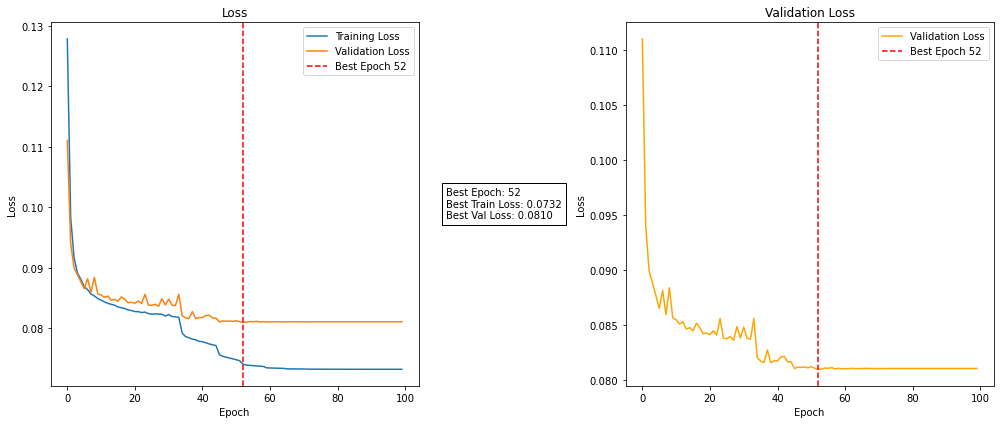

In [9]:
best_train_loss = min([epoch_data['loss'] for epoch_data in training_results])
plot_results(training_results, validation_results, best_epoch, best_train_loss, best_val_loss)

### 10. Test Final Model

Test Loss: 0.0805
RMSE: 0.2838


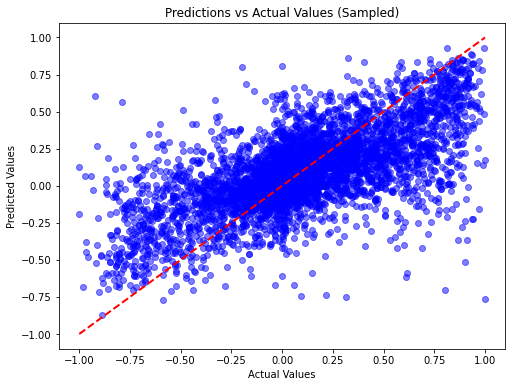

In [ ]:
final_model = GiraffeModelFinal(X_train_global.shape[1], X_train_piece.shape[1], X_train_square.shape[1],
                           best_params['global_nodes'], best_params['piece_nodes'], best_params['square_nodes'], best_params['fc_nodes'], best_params['dropout_rate']).to(device)
final_model.load_state_dict(torch.load("./models/final_giraffe_model.pth", weights_only=True))
rmse = test_model_separation(final_model, test_data)